In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

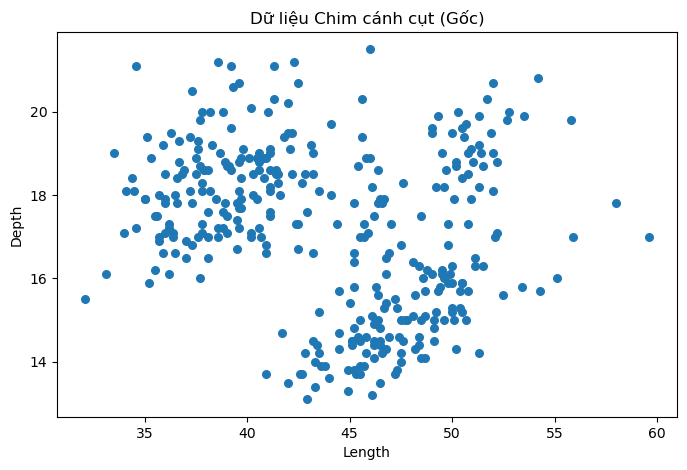

In [2]:
df = pd.read_csv('penguins.csv')

if 'bill_length_mm' in df.columns:
    cols = ['bill_length_mm', 'bill_depth_mm']
else:
    cols = ['culmen_length_mm', 'culmen_depth_mm']

X = df[cols].dropna().values

plt.figure(figsize=(8, 5))
plt.scatter(X[:,0], X[:,1], s=30)
plt.title("Dữ liệu Chim cánh cụt (Gốc)")
plt.xlabel("Length")
plt.ylabel("Depth")
plt.show()

In [ ]:
distances = linkage(X, method="ward", metric="euclidean")

print("Ma trận khoảng cách (Distances Matrix):")
print(distances[:10]) # In 10 dòng đầu

Ma trận khoảng cách (Distances Matrix):
[[2.70e+01 1.03e+02 0.00e+00 2.00e+00]
 [5.10e+01 9.90e+01 0.00e+00 2.00e+00]
 [2.40e+02 2.51e+02 0.00e+00 2.00e+00]
 [2.63e+02 2.66e+02 0.00e+00 2.00e+00]
 [2.79e+02 2.97e+02 1.00e-01 2.00e+00]
 [2.46e+02 2.89e+02 1.00e-01 2.00e+00]
 [4.70e+01 1.47e+02 1.00e-01 2.00e+00]
 [6.20e+01 9.00e+01 1.00e-01 2.00e+00]
 [2.86e+02 3.12e+02 1.00e-01 2.00e+00]
 [2.41e+02 2.73e+02 1.00e-01 2.00e+00]]


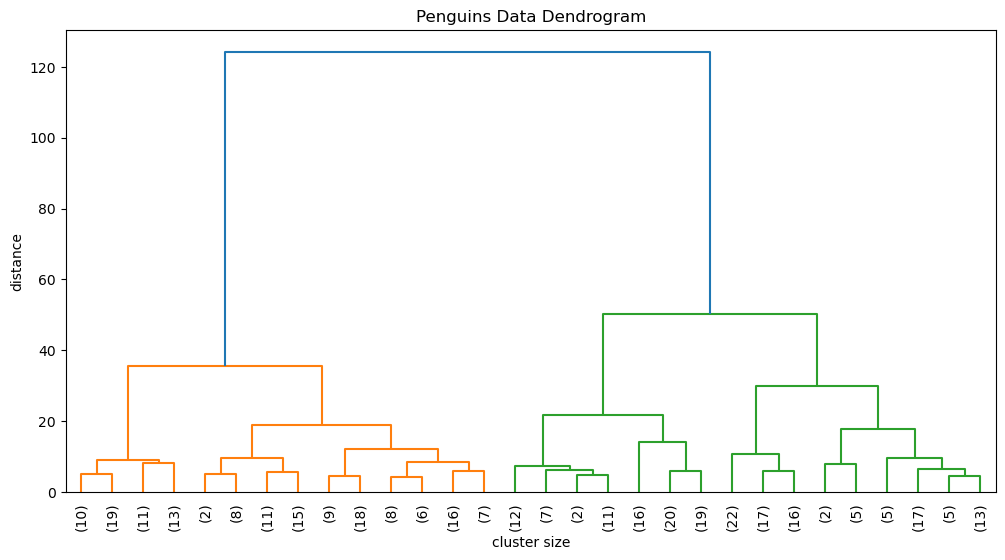

In [4]:
def annotated_dendrogram(*args, **kwargs):
    # Standard dendrogram from SciPy
    scipy_dendro = dendrogram(*args, truncate_mode='lastp', p=30, leaf_rotation=90.)
    plt.title('Penguins Data Dendrogram')
    plt.xlabel('cluster size')
    plt.ylabel('distance')
    return scipy_dendro

plt.figure(figsize=(12, 6))
dn = annotated_dendrogram(distances)
plt.show()

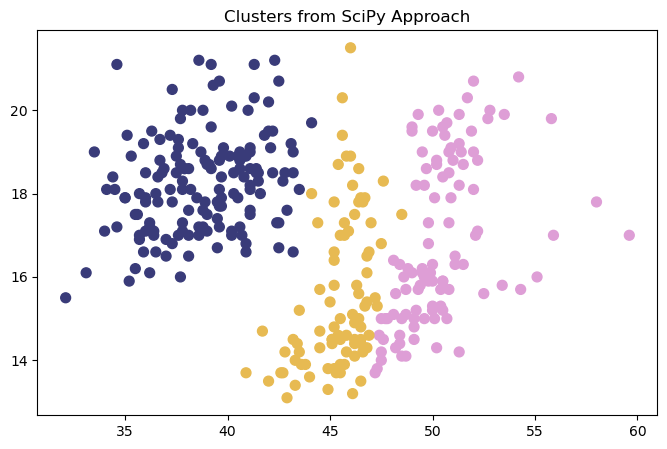

In [ ]:
# Cắt dendrogram để tạo cụm 
scipy_clusters = fcluster(distances, t=3, criterion="maxclust")
plt.figure(figsize=(8, 5))
plt.title("Clusters from SciPy Approach")
plt.scatter(X[:, 0], X[:, 1], c=scipy_clusters, s=50, cmap='tab20b')
plt.show()

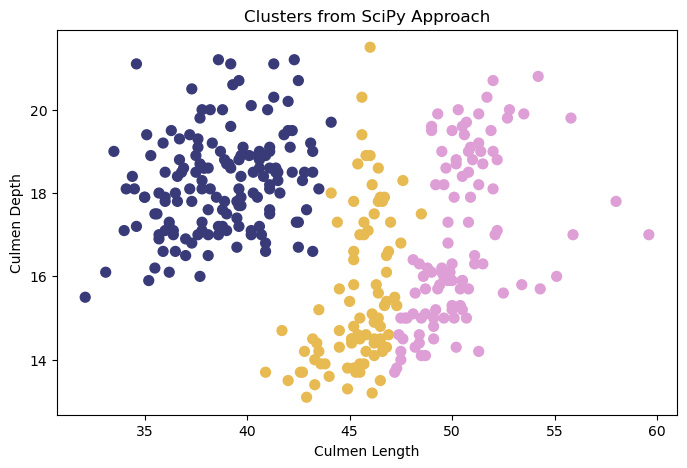

In [ ]:
# Thay đổi ngưỡng cắt để tạo cụm khác
scipy_clusters = fcluster(distances, 50, criterion="distance")

plt.figure(figsize=(8, 5))
plt.title("Clusters from SciPy Approach")

plt.scatter(X[:, 0], X[:, 1], c=scipy_clusters, s=50, cmap='tab20b')
plt.xlabel("Culmen Length")
plt.ylabel("Culmen Depth")
plt.show()

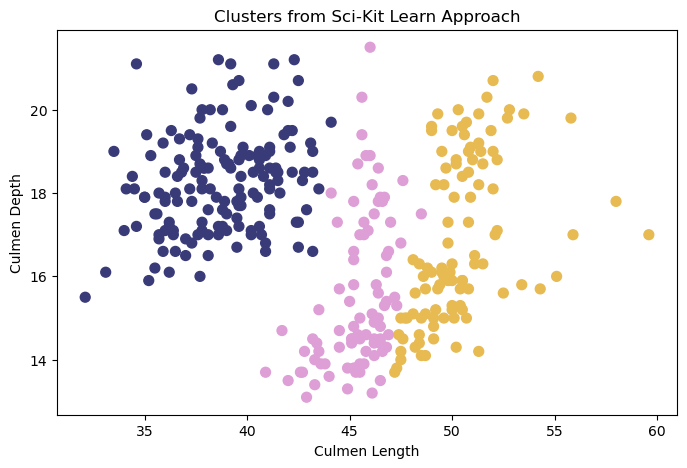

In [ ]:
# Sử dụng Sci-Kit Learn để phân cụm đa cấp
ac = AgglomerativeClustering(n_clusters=3, linkage="ward")
sklearn_clusters = ac.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.title("Clusters from Sci-Kit Learn Approach")

plt.scatter(X[:, 0], X[:, 1], c=sklearn_clusters, s=50, cmap='tab20b')

plt.xlabel("Culmen Length")
plt.ylabel("Culmen Depth")
plt.show()

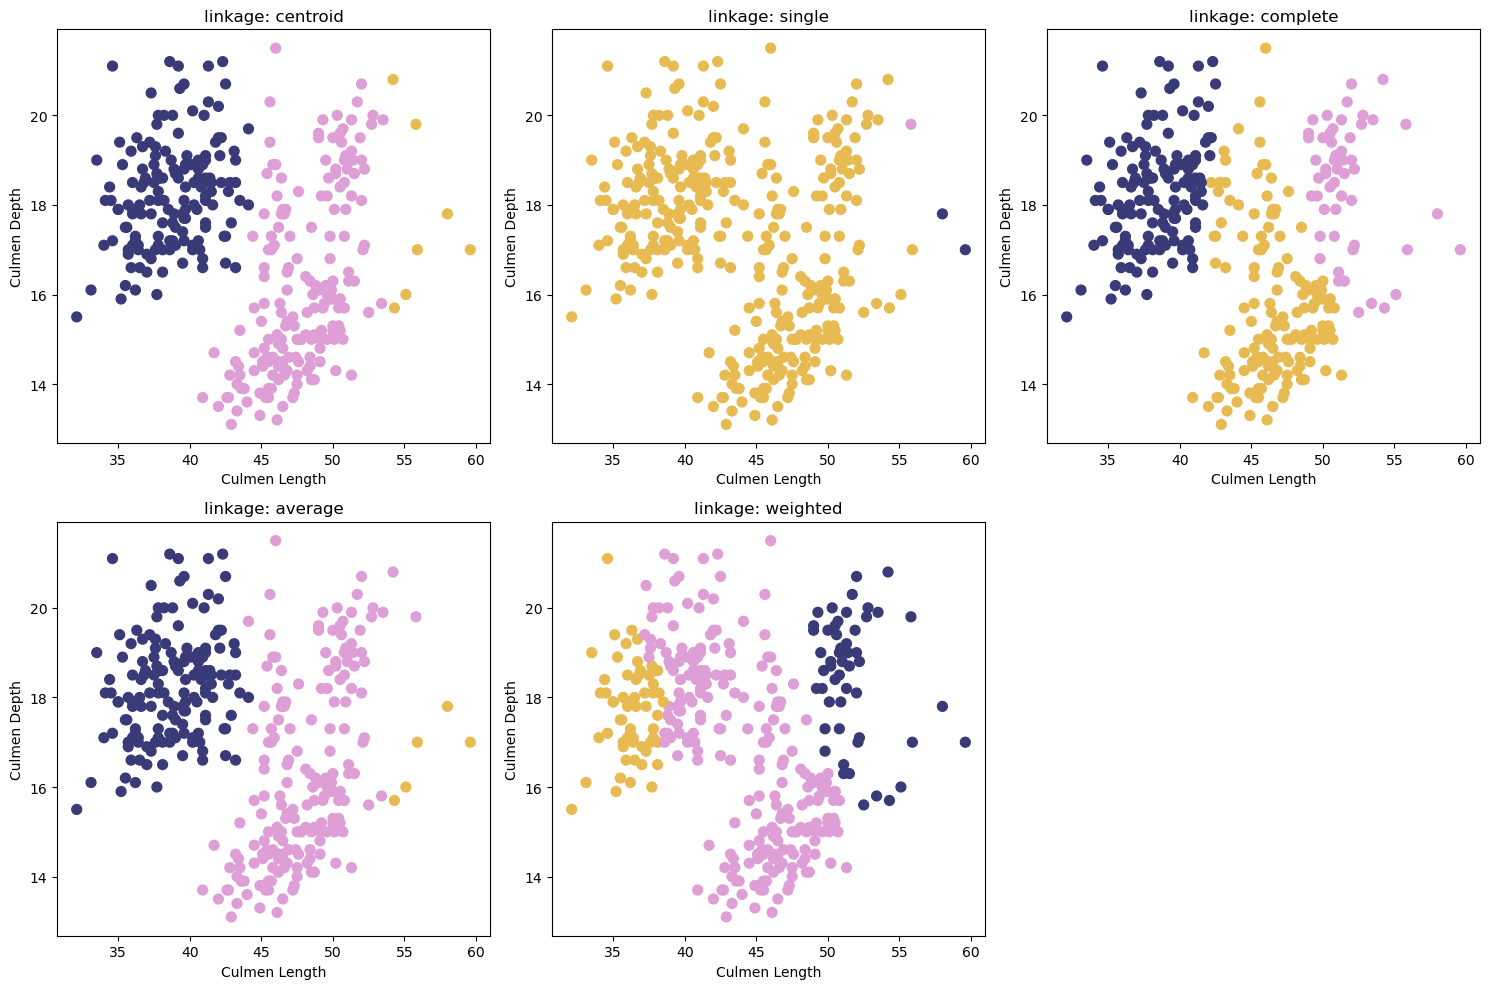

In [ ]:
# So sánh các phương pháp linkage khác nhau
methods = ['centroid', 'single', 'complete', 'average', 'weighted']
plt.figure(figsize=(15, 10))

for i, method in enumerate(methods):
    distances_method = linkage(X, method=method, metric="euclidean")
    clusters = fcluster(distances_method, t=3, criterion="maxclust") 

    plt.subplot(2, 3, i+1)
    plt.title('linkage: ' + method)
    plt.scatter(X[:,0], X[:,1], c=clusters, cmap='tab20b', s=50)
    plt.xlabel("Culmen Length")
    plt.ylabel("Culmen Depth")

plt.tight_layout()
plt.show()